# PR.2 Data Cleanser – Full Notebook

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy import stats
from scipy.stats.mstats import winsorize



### Load Dataset : Patient Health 

In [3]:
data_original = pd.read_csv("patient_health_dataset.csv")

data = data_original.copy()

data.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,36.0,Female,NaN,20.8,78.0,314.0,114.0,1
1,P0002,40.0,Female,North,30.4,104.0,NaN,88.0,1
2,P0003,48.0,Male,East,29.4,142.0,226.0,97.0,1
3,P0004,43.0,Female,South,22.6,87.0,229.0,119.0,0
4,P0005,32.0,Male,West,34.3,154.0,230.0,NaN,1


### Basic Info :

In [4]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   object 
 1   age             892 non-null    float64
 2   gender          890 non-null    object 
 3   region          897 non-null    object 
 4   bmi             902 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     906 non-null    float64
 7   glucose         914 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(1), object(3)
memory usage: 70.4+ KB
None
              age         bmi  blood_pressure  cholesterol     glucose  \
count  892.000000  902.000000     1000.000000   906.000000  914.000000   
mean    46.735426   27.739517      132.804458   236.356529  115.582853   
std     12.995620    6.361704       26.221164    59.013879   36.706454   
min     25.000000    9.100000       

### Missing Value Identification:

In [5]:
missing_count = data.isnull().sum()
missing_percent = (missing_count / len(data)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing_count,
    "Percentage (%)": missing_percent
})

missing_df

,Missing Count,Percentage (%)
patient_id,0,0.0
age,108,10.8
gender,110,11.0
region,103,10.3
bmi,98,9.8
blood_pressure,0,0.0
cholesterol,94,9.4
glucose,86,8.6
disease_risk,0,0.0


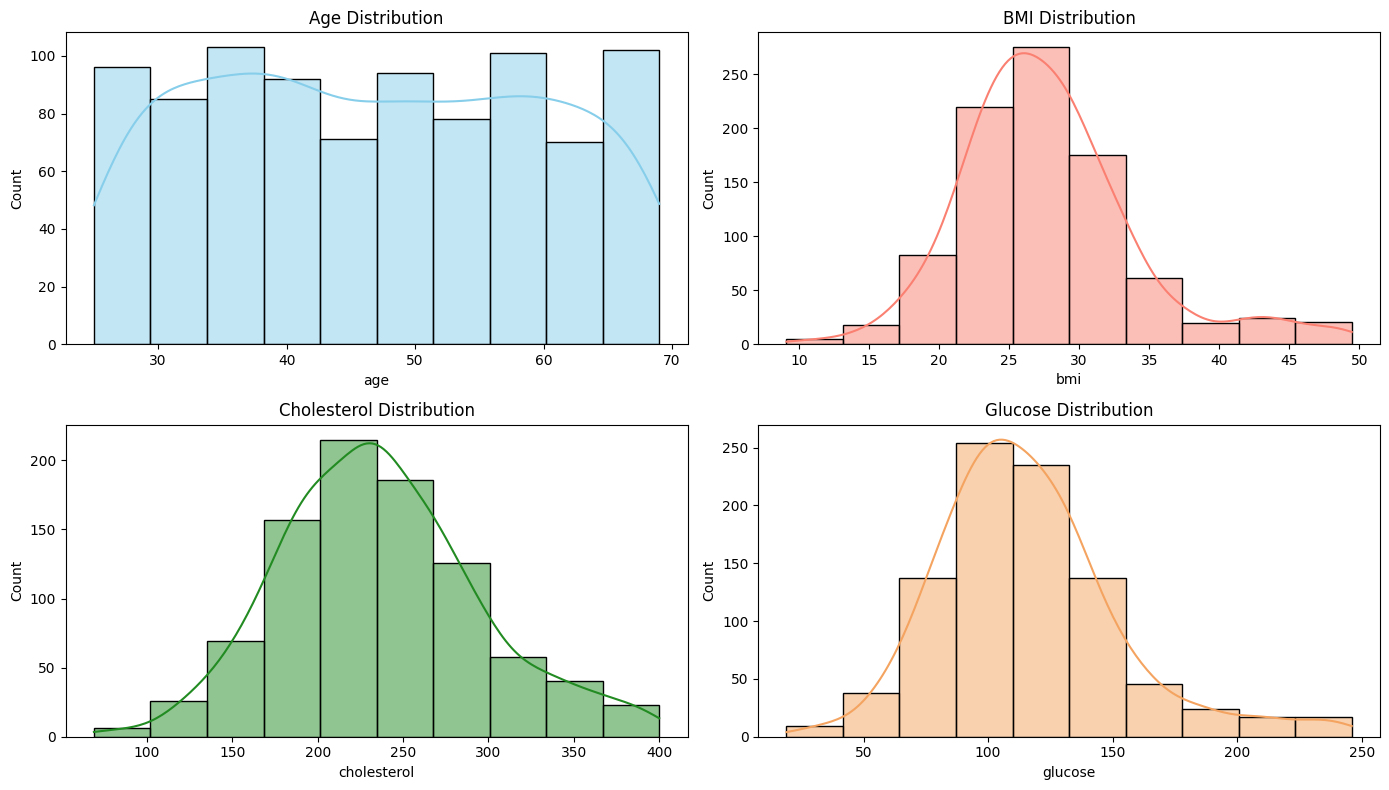

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.histplot(data['age'], bins=10, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Age Distribution')

sns.histplot(data['bmi'], bins=10, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('BMI Distribution')

sns.histplot(data['cholesterol'], bins=10, kde=True, ax=axes[1,0], color='forestgreen')
axes[1,0].set_title('Cholesterol Distribution')

sns.histplot(data['glucose'], bins=10, kde=True, ax=axes[1,1], color='sandybrown')
axes[1,1].set_title('Glucose Distribution')

plt.tight_layout()
plt.show()


### Handle Missing Values :

#### For Numerical Feature :

In [7]:
data["age"] = SimpleImputer(strategy="mean").fit_transform(data[["age"]])
data["bmi"] = SimpleImputer(strategy="median").fit_transform(data[["bmi"]])
data["cholesterol"] = SimpleImputer(strategy="median").fit_transform(data[["cholesterol"]])
data["glucose"] = SimpleImputer(strategy="median").fit_transform(data[["glucose"]])

#### For Categorical Feature :

In [8]:
def random_impute_cat(data, col):
    probs = data[col].value_counts(normalize=True)
    missing = data[col].isnull()
    
    data.loc[missing, col] = np.random.choice(
        probs.index,
        size=missing.sum(),
        p=probs.values
    )

random_impute_cat(data, "gender")
random_impute_cat(data, "region")


#### KNN and MICE :

In [9]:
num_cols = ["age", "bmi", "cholesterol", "glucose"]

In [10]:
data_knn = data.copy()
knn_imputer = KNNImputer(n_neighbors=7)
data_knn[num_cols] = knn_imputer.fit_transform(data_knn[num_cols])

In [11]:
data_mice = data.copy()
mice_imputer = IterativeImputer(random_state=42)
data_mice[num_cols] = mice_imputer.fit_transform(data_mice[num_cols])

In [12]:
data_before_outliers = data.copy()

### Handling Outliers :

In [13]:
cols = ["cholesterol", "glucose"]

z = (data[cols] - data[cols].mean()) / data[cols].std()

outliers_z = data[(np.abs(z) > 3).any(axis=1)]

print("Z-score Outliers:", outliers_z.shape[0])


Z-score Outliers: 18


In [14]:
col = "bmi"

Q1 = data[col].quantile(0.25)
Q3 = data[col].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_iqr = data[(data[col] < lower) | (data[col] > upper)]

print("BMI Outliers:", outliers_iqr.shape[0])


BMI Outliers: 64


In [15]:
data_after_outliers = data.copy()

cols = ["bmi", "cholesterol", "glucose"]

for col in cols:
    data_after_outliers[col] = winsorize(data_after_outliers[col], limits=[0.01, 0.01])


### Comparison :

In [16]:
print("\nShape Comparison:")
print("Before:", data_before_outliers.shape)
print("After :", data_after_outliers.shape)

print("\nSummary BEFORE:")
print(data_before_outliers[cols].describe())

print("\nSummary AFTER:")
print(data_after_outliers[cols].describe())


Shape Comparison:
Before: (1000, 9)
After : (1000, 9)

Summary BEFORE:
               bmi  cholesterol      glucose
count  1000.000000  1000.000000  1000.000000
mean     27.667044   235.947015   115.188727
std       6.045619    56.183273    35.114485
min       9.100000    69.000000    19.000000
25%      24.100000   200.000000    94.000000
50%      27.000000   232.000000   111.000000
75%      30.225000   266.250000   131.000000
max      49.457380   400.000000   246.021414

Summary AFTER:
               bmi  cholesterol      glucose
count  1000.000000  1000.000000  1000.000000
mean     27.675513   236.115767   115.225752
std       5.944389    55.495093    34.617224
min      15.000000   116.000000    43.000000
25%      24.100000   200.000000    94.000000
50%      27.000000   232.000000   111.000000
75%      30.225000   266.250000   131.000000
max      47.475746   388.147158   233.046842


### Visual Comparison :

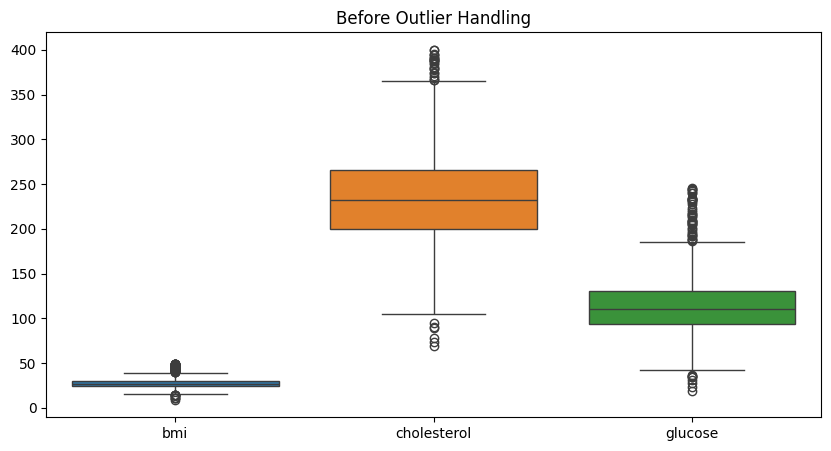

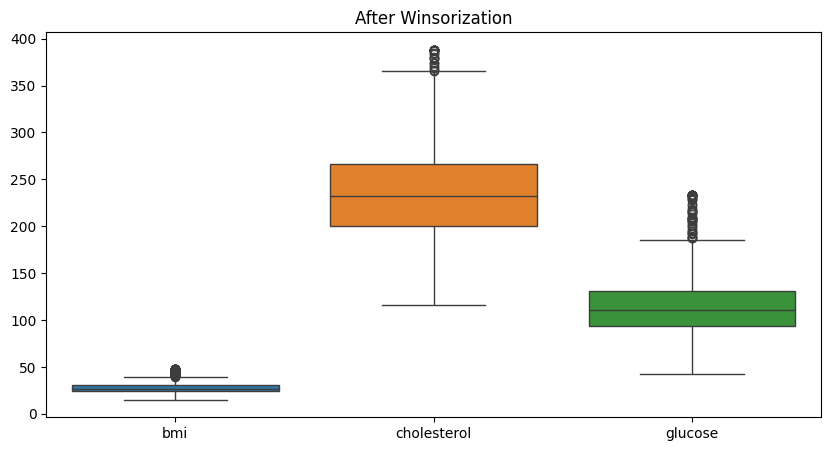

In [17]:
plt.figure(figsize=(10,5))
sns.boxplot(data=data_before_outliers[cols])
plt.title("Before Outlier Handling")
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=data_after_outliers[cols])
plt.title("After Winsorization")
plt.show()


In [18]:
data_after_outliers.to_csv("cleaned_dataset.csv", index=False)

In [20]:
Final_Dataset = pd.read_csv("cleaned_dataset.csv")
Final_Dataset

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P0001,36.000000,Female,South,20.800000,78.0,314.0,114.0,1
1,P0002,40.000000,Female,North,30.400000,104.0,232.0,88.0,1
2,P0003,48.000000,Male,East,29.400000,142.0,226.0,97.0,1
3,P0004,43.000000,Female,South,22.600000,87.0,229.0,119.0,0
4,P0005,32.000000,Male,West,34.300000,154.0,230.0,111.0,1
...,...,...,...,...,...,...,...,...,...
995,P0996,46.735426,Male,West,24.100000,110.0,245.0,51.0,0
996,P0997,55.000000,Male,South,24.300000,101.0,245.0,114.0,0
997,P0998,38.000000,Male,South,44.375977,132.0,322.0,100.0,1
998,P0999,25.000000,Male,East,29.100000,158.0,269.0,111.0,1
